<a href="https://colab.research.google.com/github/LaraAlmani/IT326/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Data Summarization and Preprocessing
**Dataset:** Student Performance Dataset (750 records, 15 attributes)  
**Class label:** `final_grade` (A, B, C, D, F)

The raw dataset is loaded into `raw_df` and never modified. All preprocessing is done on a copy (`df`), and the result `Preprocessed_dataset.csv`.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import micropip
#await micropip.install("seaborn")
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")


raw_df = pd.read_csv("student_performance_dataset.csv")


df = raw_df.copy()

numeric_cols = ["age", "study_hours", "attendance_rate", "assignment_score",
                "midterm_score", "final_score", "sleep_hours", "stress_level"]
categorical_cols = ["gender", "internet_access", "parent_education",
                    "part_time_job", "extracurricular"]
target = "final_grade"

print("Shape:", raw_df.shape)
raw_df.head()

Shape: (750, 15)


,student_id,age,gender,study_hours,attendance_rate,assignment_score,midterm_score,final_score,internet_access,parent_education,sleep_hours,part_time_job,stress_level,extracurricular,final_grade
0,1,24,Female,3.06,69.94,82.42,66.39,81.68,No,PhD,7.48,Yes,2,Yes,B
1,2,21,Male,3.26,65.35,76.87,34.85,83.17,Yes,High School,6.87,Yes,6,No,F
2,3,22,Female,4.63,76.74,88.63,68.55,58.15,No,Bachelor,7.38,No,7,No,F
3,4,24,Female,3.42,91.61,66.68,83.50,79.49,Yes,High School,7.69,No,3,Yes,F
4,5,20,Male,2.15,83.29,73.93,70.08,74.38,Yes,Master,6.01,No,9,Yes,F


# 1. Data Analysis

## 1.1 Statistical Summaries

In [10]:
raw_df.info()
print()
raw_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        750 non-null    int64  
 1   age               750 non-null    int64  
 2   gender            750 non-null    object 
 3   study_hours       750 non-null    float64
 4   attendance_rate   750 non-null    float64
 5   assignment_score  750 non-null    float64
 6   midterm_score     750 non-null    float64
 7   final_score       750 non-null    float64
 8   internet_access   750 non-null    object 
 9   parent_education  750 non-null    object 
 10  sleep_hours       750 non-null    float64
 11  part_time_job     750 non-null    object 
 12  stress_level      750 non-null    int64  
 13  extracurricular   750 non-null    object 
 14  final_grade       750 non-null    object 
dtypes: float64(6), int64(3), object(6)
memory usage: 88.0+ KB



,count,mean,std,min,25%,50%,75%,max
student_id,750.0,375.500000,216.650640,1.00,188.2500,375.500,562.7500,750.00
age,750.0,20.950667,2.004393,18.00,19.0000,21.000,23.0000,24.00
study_hours,750.0,4.014920,1.568160,-1.35,3.0400,4.070,5.1100,8.71
attendance_rate,750.0,79.747587,11.703691,60.01,69.1175,79.730,89.9775,99.99
assignment_score,750.0,76.017907,10.370385,45.86,69.2000,76.445,82.6575,107.60
midterm_score,750.0,69.406987,11.775280,31.13,61.6925,69.660,77.3050,103.01
final_score,750.0,72.494853,14.585081,32.46,62.7600,72.415,82.4750,126.87
sleep_hours,750.0,7.030920,1.027692,3.87,6.3125,7.035,7.7300,9.77
stress_level,750.0,5.064000,2.559030,1.00,3.0000,5.000,7.0000,9.00


**Description:** `info()` shows the data types and `describe()` gives count, mean, std, min, quartiles and max for every numeric attribute.  
**What it tells us:** Several values are impossible for this kind of data: `study_hours` has a negative minimum (-1.35), and `assignment_score`, `midterm_score` and `final_score` have maximums above 100 (107.6, 103.0 and 126.9). Also the attributes are on different scales (`attendance_rate` around 60-100, `stress_level` 1-9, `study_hours` around 0-9).  
**Decision:** The data needs noise/outlier treatment and normalization.

## 1.2 Missing Values Analysis

In [11]:
missing = pd.DataFrame({
    "missing_count": raw_df.isnull().sum(),
    "missing_percent": (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
})
print(missing)
print()
print("Duplicated rows:", raw_df.duplicated().sum())

                  missing_count  missing_percent
student_id                    0              0.0
age                           0              0.0
gender                        0              0.0
study_hours                   0              0.0
attendance_rate               0              0.0
assignment_score              0              0.0
midterm_score                 0              0.0
final_score                   0              0.0
internet_access               0              0.0
parent_education              0              0.0
sleep_hours                   0              0.0
part_time_job                 0              0.0
stress_level                  0              0.0
extracurricular               0              0.0
final_grade                   0              0.0

Duplicated rows: 0


**Description:** Count and percentage of missing values per attribute, plus a check for duplicated rows.  
**What it tells us:** There are no missing values in any attribute and no duplicated rows.  
**Decision:** No imputation or row removal is needed.

## 1.3 Five Number Summary and Outliers (IQR method)

In [12]:
rows = []
for col in numeric_cols:
    q1 = raw_df[col].quantile(0.25)
    q3 = raw_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((raw_df[col] < lower) | (raw_df[col] > upper)).sum()
    rows.append([col, raw_df[col].min(), q1, raw_df[col].median(), q3,
                 raw_df[col].max(), round(lower, 2), round(upper, 2), n_out])

summary = pd.DataFrame(rows, columns=["attribute", "min", "Q1", "median", "Q3",
                                      "max", "lower_bound", "upper_bound", "outliers"])
summary

,attribute,min,Q1,median,Q3,max,lower_bound,upper_bound,outliers
0,age,18.00,19.0000,21.000,23.0000,24.00,13.00,29.00,0
1,study_hours,-1.35,3.0400,4.070,5.1100,8.71,-0.07,8.22,6
2,attendance_rate,60.01,69.1175,79.730,89.9775,99.99,37.83,121.27,0
3,assignment_score,45.86,69.2000,76.445,82.6575,107.60,49.01,102.84,7
4,midterm_score,31.13,61.6925,69.660,77.3050,103.01,38.27,100.72,7
5,final_score,32.46,62.7600,72.415,82.4750,126.87,33.19,112.05,3
6,sleep_hours,3.87,6.3125,7.035,7.7300,9.77,4.19,9.86,3
7,stress_level,1.00,3.0000,5.000,7.0000,9.00,-3.00,13.00,0


**Description:** For each numeric attribute: min, Q1, median, Q3, max, the IQR bounds (Q1 - 1.5*IQR and Q3 + 1.5*IQR) and the number of outliers outside them.  
**What it tells us:** Outliers exist in `study_hours` (6), `assignment_score` (7), `midterm_score` (7), `final_score` (3) and `sleep_hours` (3). `age`, `attendance_rate` and `stress_level` have none.  
**Decision:** Outlier treatment is needed on the five attributes above.

## 1.4 Boxplots (numeric attributes)

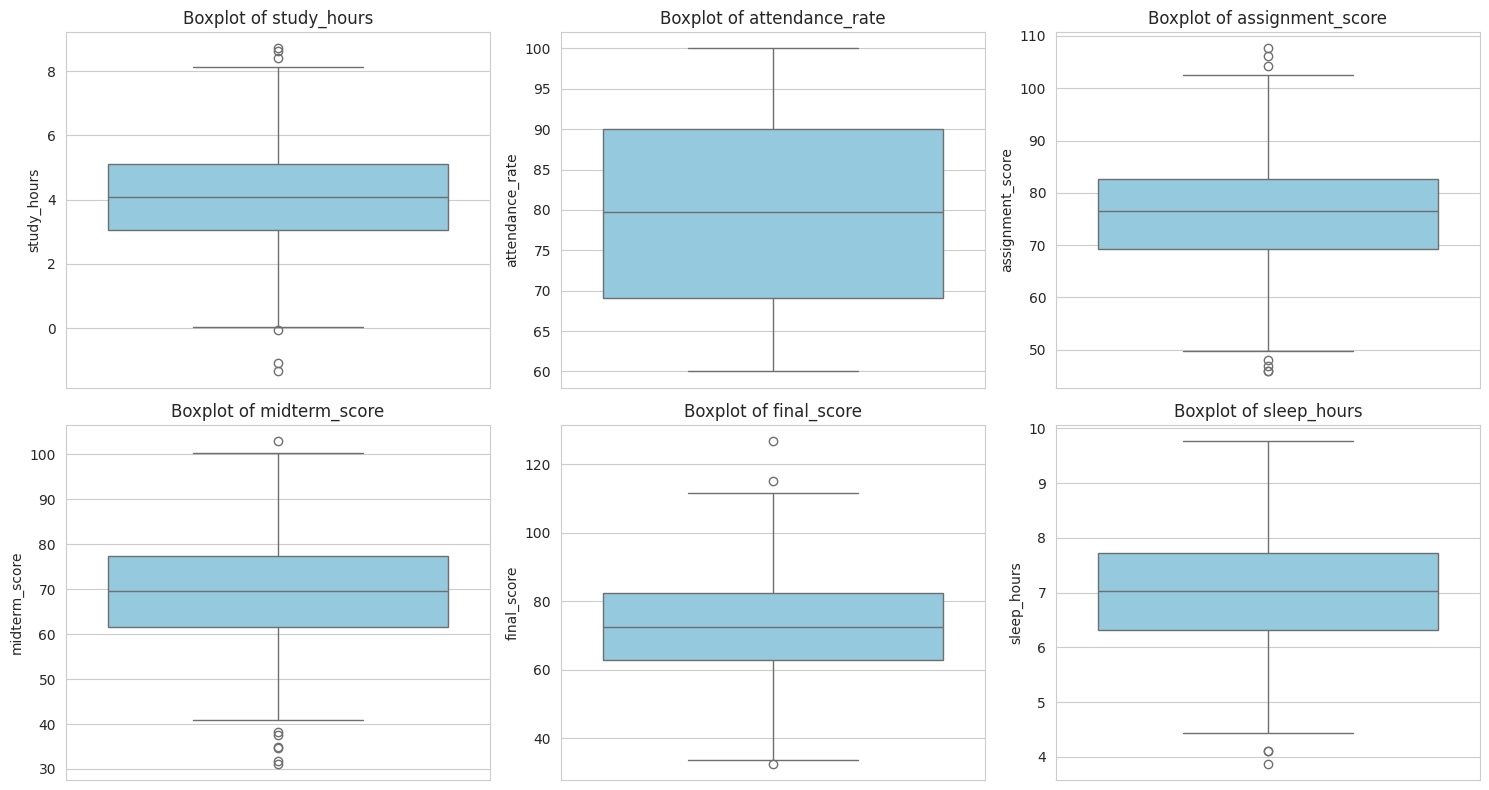

In [13]:
plot_cols = ["study_hours", "attendance_rate", "assignment_score",
             "midterm_score", "final_score", "sleep_hours"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(y=raw_df[col], ax=ax, color="skyblue")
    ax.set_title("Boxplot of " + col)
plt.tight_layout()
plt.show()

**Description:** Each boxplot shows the median, the quartiles (box) and the whiskers; points beyond the whiskers are outliers.  
**What it tells us:** `study_hours`, `assignment_score`, `midterm_score`, `final_score` and `sleep_hours` show points outside the whiskers on one or both sides, while `attendance_rate` is clean. Some of these points are not just extreme, they are invalid (negative study hours, scores above 100).  
**Decision:** Apply IQR capping and also limit the values to their valid range.

## 1.5 Histograms (variable distributions of numeric attributes)

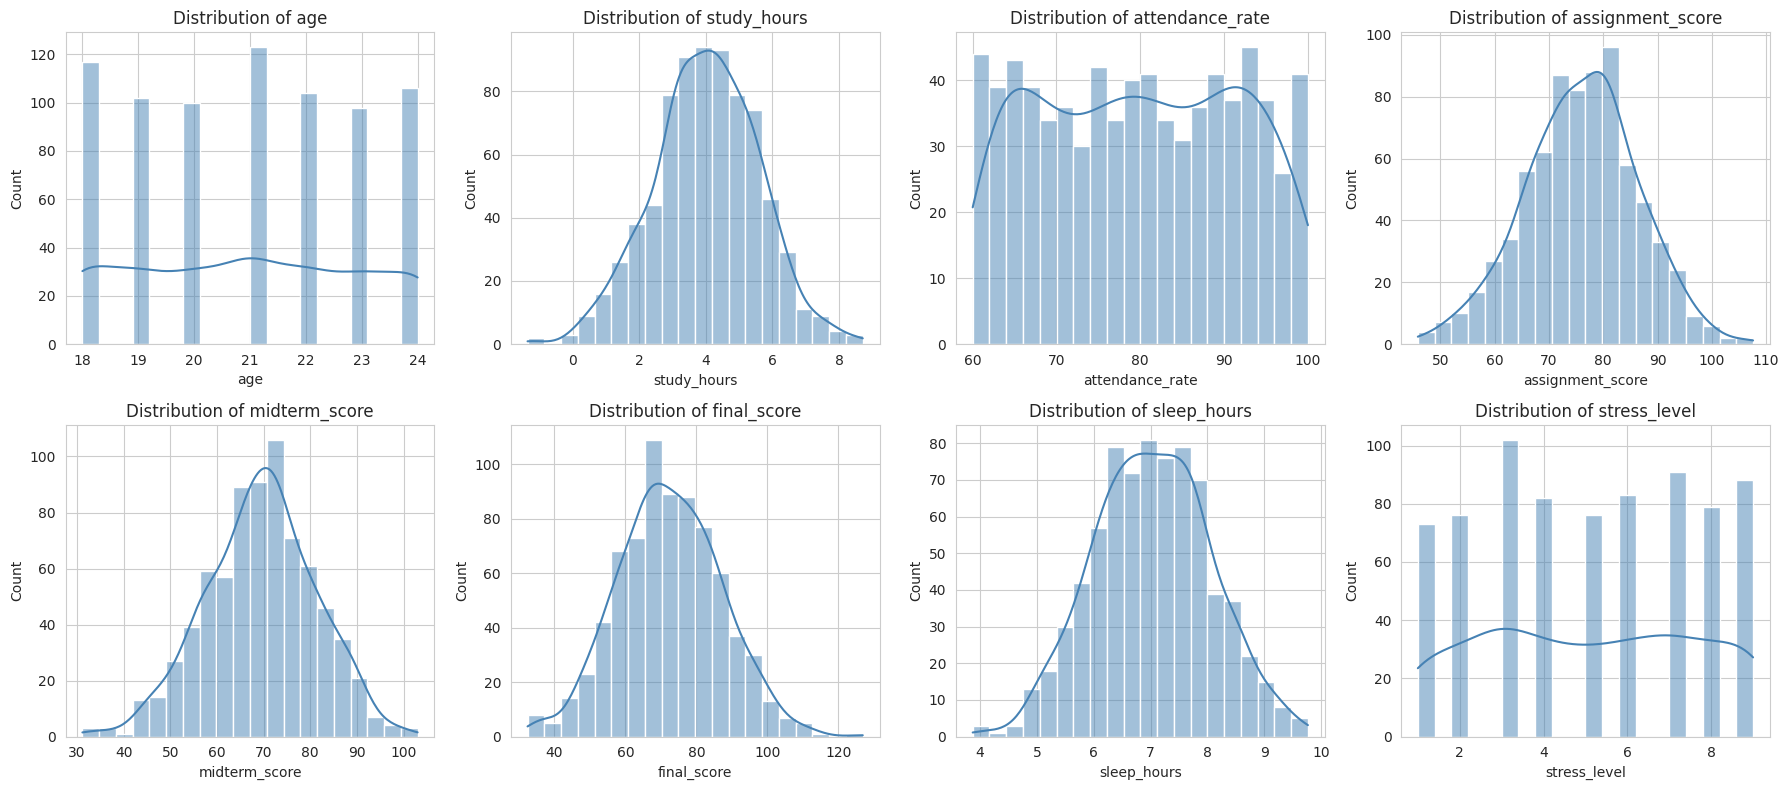

age                 0.02
study_hours        -0.09
attendance_rate     0.01
assignment_score   -0.11
midterm_score      -0.14
final_score         0.09
sleep_hours         0.01
stress_level        0.00
dtype: float64


In [14]:
hist_cols = ["age", "study_hours", "attendance_rate", "assignment_score",
             "midterm_score", "final_score", "sleep_hours", "stress_level"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), hist_cols):
    sns.histplot(raw_df[col], bins=20, kde=True, ax=ax, color="steelblue")
    ax.set_title("Distribution of " + col)
plt.tight_layout()
plt.show()

print(raw_df[hist_cols].skew().round(2))

**Description:** Histograms with a density curve show the distribution shape of each numeric attribute, and `skew()` measures its asymmetry.  
**What it tells us:** Most attributes are roughly symmetric and bell-shaped (skewness close to 0), so no skew correction (log transform) is required. The scores show long thin tails beyond 100, which confirms the outliers. The ranges of the attributes are very different from each other.  
**Decision:** Normalization is needed so that all attributes are on the same scale.

## 1.6 Scatter Plots

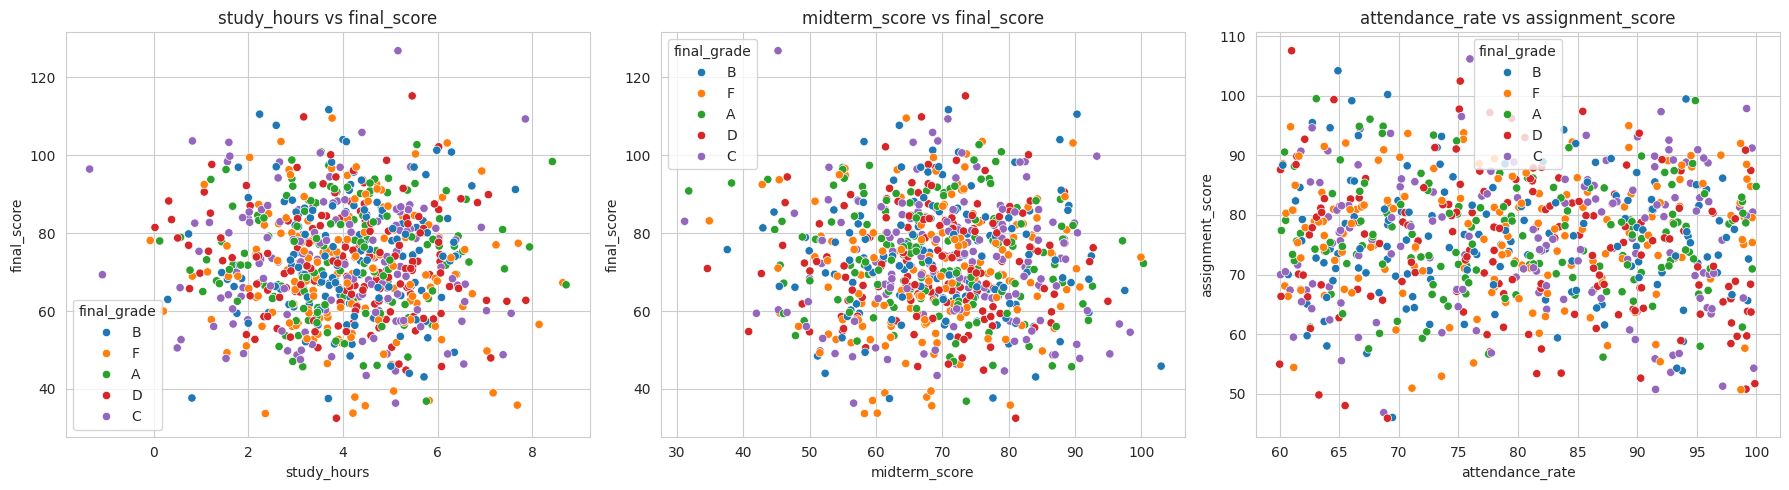

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=raw_df, x="study_hours", y="final_score", hue=target, ax=axes[0])
axes[0].set_title("study_hours vs final_score")
sns.scatterplot(data=raw_df, x="midterm_score", y="final_score", hue=target, ax=axes[1])
axes[1].set_title("midterm_score vs final_score")
sns.scatterplot(data=raw_df, x="attendance_rate", y="assignment_score", hue=target, ax=axes[2])
axes[2].set_title("attendance_rate vs assignment_score")
plt.tight_layout()
plt.show()

**Description:** Scatter plots of pairs of numeric attributes, coloured by the class label.  
**What it tells us:** The points are spread without a clear pattern (no strong linear relationship between the pairs), and the grade colours are mixed everywhere. The extreme points (negative `study_hours`, `final_score` above 100) are clearly separated from the main cloud.  
**Decision:** Confirms that the extreme points are noise that should be treated.

## 1.7 Bar Plots (nominal attributes)

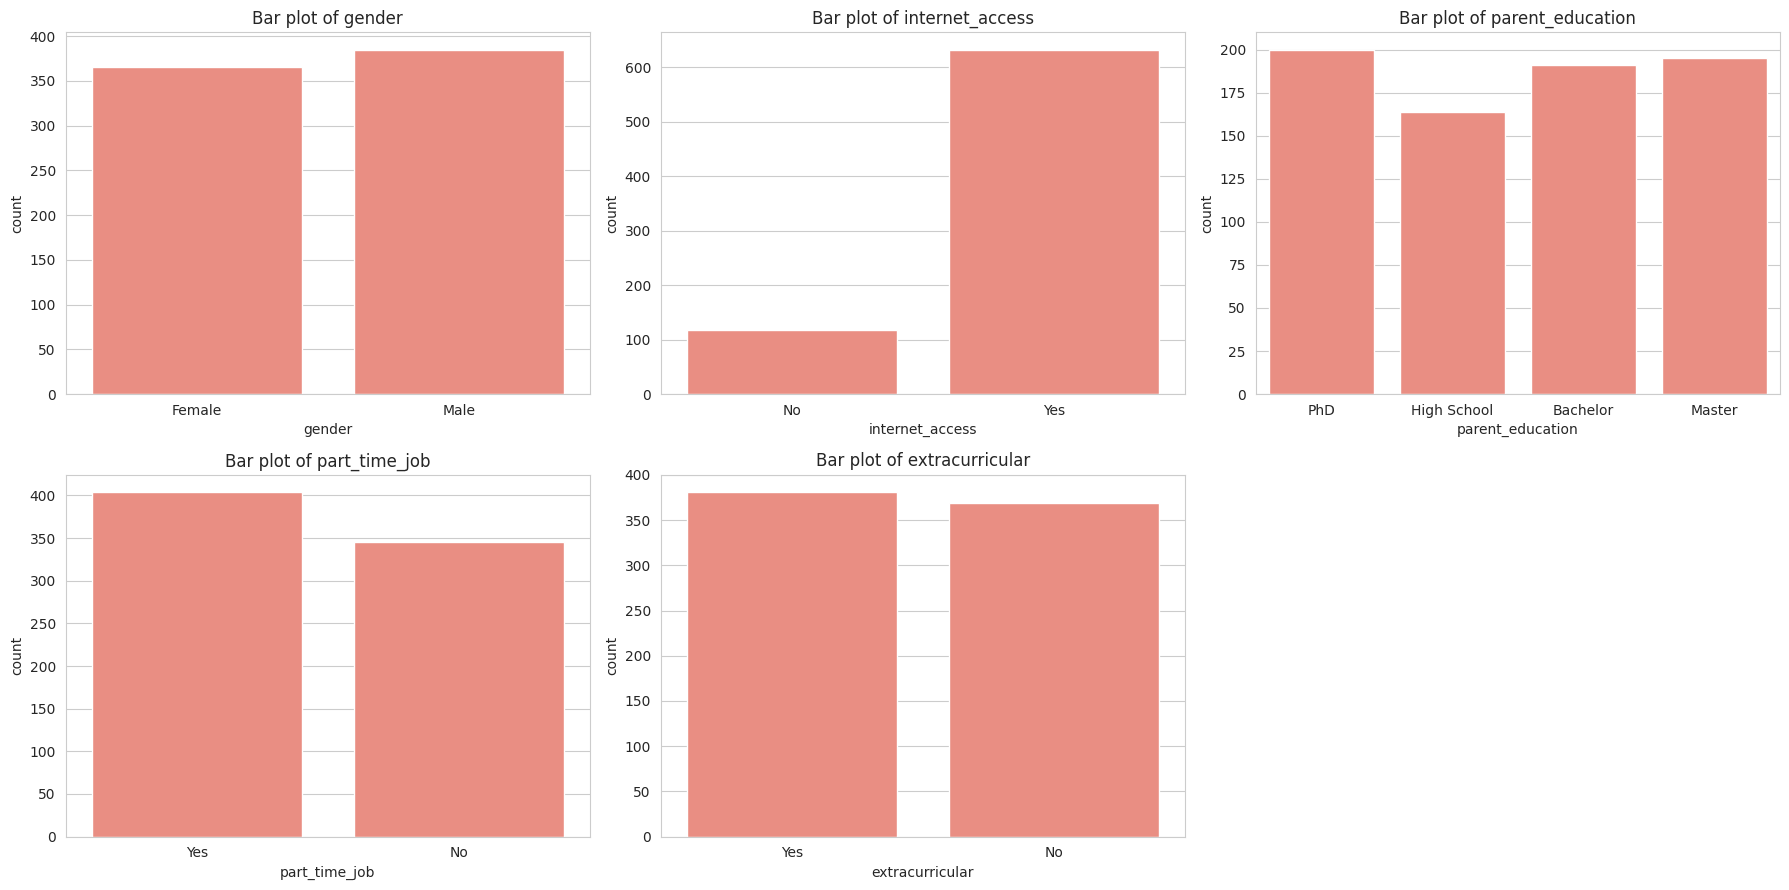

gender
Male      385
Female    365
Name: count, dtype: int64

internet_access
Yes    632
No     118
Name: count, dtype: int64

parent_education
PhD            200
Master         195
Bachelor       191
High School    164
Name: count, dtype: int64

part_time_job
Yes    404
No     346
Name: count, dtype: int64

extracurricular
Yes    381
No     369
Name: count, dtype: int64



In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=raw_df, x=col, ax=ax, color="salmon")
    ax.set_title("Bar plot of " + col)
axes[1][2].axis("off")
plt.tight_layout()
plt.show()

for col in categorical_cols:
    print(raw_df[col].value_counts())
    print()

**Description:** Bar plots of the count of each category in the nominal attributes.  
**What it tells us:** The categories are fairly balanced, except `internet_access` (632 Yes vs 118 No). `gender`, `internet_access`, `part_time_job` and `extracurricular` have two values, and `parent_education` has four values (High School, Bachelor, Master, PhD) with a natural order. These attributes are stored as text.  
**Decision:** Categorical variable transformation is needed because the algorithms require numeric input.

## 1.8 Class Label Distribution

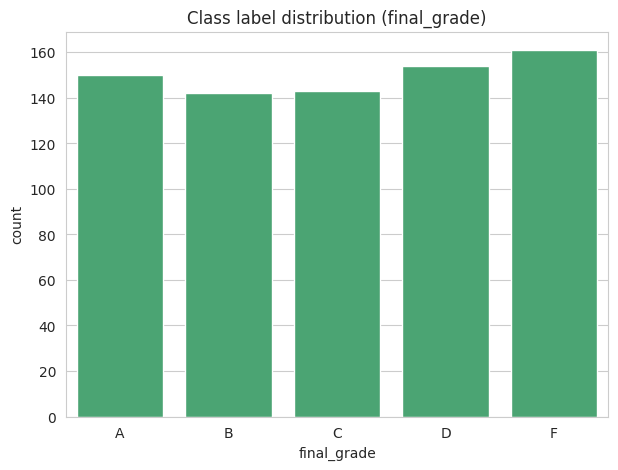

final_grade
A    150
B    142
C    143
D    154
F    161
Name: count, dtype: int64

final_grade
A    20.0
B    18.9
C    19.1
D    20.5
F    21.5
Name: proportion, dtype: float64


In [17]:
order = ["A", "B", "C", "D", "F"]
plt.figure(figsize=(7, 5))
sns.countplot(data=raw_df, x=target, order=order, color="mediumseagreen")
plt.title("Class label distribution (final_grade)")
plt.show()

print(raw_df[target].value_counts().reindex(order))
print()
print((raw_df[target].value_counts(normalize=True).reindex(order) * 100).round(1))

**Description:** Number of records in each class of `final_grade`.  
**What it tells us:** The five classes are almost balanced (A 150, B 142, C 143, D 154, F 161), so there is no class imbalance problem.  
**Decision:** No resampling is needed. The class label itself is kept unchanged.

# 2. Data Preprocessing

According to the phase guidelines, we apply appropriate preprocessing tasks chosen from the recommended techniques: **Discretization**, **Noise Removal** and  **Normalization**.

## 2.1 Discretization

In [18]:
column_to_discretize = "age"
num_bins = 3
df["discretized_age"] = pd.cut(
    df[column_to_discretize],
    bins=num_bins,
    labels=["Young", "Middle", "Older"])
print("Original DataFrame:")
print(df[["age", "discretized_age"]].head(15))

Original DataFrame:
    age discretized_age
0    24           Older
1    21          Middle
2    22          Middle
3    24           Older
4    20           Young
5    22          Middle
6    22          Middle
7    24           Older
8    19           Young
9    20           Young
10   24           Older
11   20           Young
12   20           Young
13   22          Middle
14   21          Middle


In [ ]:
column_to_discretize = "study_hours"
num_bins = 3
df["discretized_study_hours"] = pd.cut(
    df[column_to_discretize],
    bins=num_bins,
    labels=["Low", "Medium", "High"])
print("Original DataFrame:")
print(df[["study_hours", "discretized_study_hours"]].head(15))

Original DataFrame:
    study_hours discretized_study_hours
0          3.06                  Medium
1          3.26                  Medium
2          4.63                  Medium
3          3.42                  Medium
4          2.15                     Low
5          2.35                     Low
6          4.81                  Medium
7          1.96                     Low
8          6.10                    High
9          2.96                  Medium
10         4.92                  Medium
11         3.05                  Medium
12         2.63                     Low
13         4.37                  Medium
14         5.58                  Medium


**Description:**

Discretization was applied to the Age and Study Hours attributes using pd.cut(). These attributes were selected because they are numerical and can be meaningfully grouped into categories. Age was divided into Young, Middle, and Older, while Study Hours was divided into Low, Medium, and High. This transformation makes the values easier to interpret and analyze by converting continuous numerical values into categorical groups.

## *2.2* Noise Removal

In [19]:
print("--- Preprocessing: Noise Removal (Domain Boundary Clamping) ---")

df["study_hours"] = df["study_hours"].clip(lower=0.0)
for col in ["assignment_score", "midterm_score", "final_score"]:
  df[col] = df[col].clip(upper=100.0)

print("Updated ranges after domain boundary clamping:")
df[["study_hours", "assignment_score", "midterm_score", "final_score"]].describe().T[["min", "mean", "max"]]

--- Preprocessing: Noise Removal (Domain Boundary Clamping) ---
Updated ranges after domain boundary clamping:


,min,mean,max
study_hours,0.00,4.018253,8.71
assignment_score,45.86,75.990187,100.00
midterm_score,31.13,69.402507,100.00
final_score,32.46,72.312093,100.00


**Justification:** For the `study_hours`,`assignment_score`, `midterm_score`, `final_score`; We notice that negative hours of study and scores above $100$ are domain-impossible values resulting from data entry errors or uncalibrated extra credit.   
**Method:** Domain boundary clamping by setting the lower threshold of `study_hours` to $0.0$ and capping `assignment_score`, `midterm_score`, and `final_score` at $100.0$.   
**Improvement:** Corrects data corruption while preserving the relative standing of top-scoring and low-studying students, avoiding the distortion caused by replacing valid high or low efforts with an artificial central median value.

In [2]:
## 2.3 Normalization

In [20]:
# Check the ranges of numeric attributes before normalization
numeric_cols = df.select_dtypes(include=np.number).columns

print("Numeric attribute ranges:")
df[numeric_cols].agg(["min", "max"]).T

Numeric attribute ranges:


,min,max
student_id,1.00,750.00
age,18.00,24.00
study_hours,0.00,8.71
attendance_rate,60.01,99.99
assignment_score,45.86,100.00
midterm_score,31.13,100.00
final_score,32.46,100.00
sleep_hours,3.87,9.77
stress_level,1.00,9.00


In [21]:
# Numerical attributes to normalize
cols_to_normalize = [
    "age",
    "study_hours",
    "attendance_rate",
    "assignment_score",
    "midterm_score",
    "final_score",
    "sleep_hours",
    "stress_level"
]

# Apply Min-Max normalization
scaler = MinMaxScaler()

df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print("Ranges after Min-Max normalization:")
df[cols_to_normalize].agg(["min", "max"]).T

Ranges after Min-Max normalization:


,min,max
age,0.0,1.0
study_hours,0.0,1.0
attendance_rate,0.0,1.0
assignment_score,0.0,1.0
midterm_score,0.0,1.0
final_score,0.0,1.0
sleep_hours,0.0,1.0
stress_level,0.0,1.0


Normalizzation:
Min-Max normalization was applied to the numerical attributes: `age`, `study_hours`, `attendance_rate`, `assignment_score`, `midterm_score`, `final_score`, `sleep_hours`, and `strees_level`. The attribute `student_id` was execluded because it is and identifier rather than a numerical feature used for analyis.
Min_Max normalization transforms each selected attribute to the range [0, 1]. This prevents attributes with larger numerical ranges from having a greater influence on distance_based data mining methods.


In [22]:
# Save the fully preprocessed dataset
df.to_csv("Preprocessed_dataset.csv", index=False)

print("Preprocessed dataset saved successfully!")
print("Final shape:", df.shape)

Preprocessed dataset saved successfully!
Final shape: (750, 16)
